---
title: "Лабораторна робота №6. Класифікація текстових документів"
description: "Технології аналізу текстової інформації та машинне навчання | КрНУ ім. М. Остроградського"
author: "&copy; Роменський В'ячеслав, 2026"
date: today
lang: uk
jupyter: python3

format:
  html:
    toc: true
    toc-location: right
    number-sections: false
    code-fold: true
    embed-resources: true
    self-contained-math: true
---


## Мета роботи

Опанувати базові підходи до *класифікації текстових документів*: підготовку розміченого корпусу, побудову *TF-IDF*-представлення, навчання моделей *Naive Bayes*, *Logistic Regression* та *Linear SVM*, а також оцінювання якості класифікації за допомогою основних метрик.


## Постановка завдання

Потрібно сформувати *навчальний корпус документів* і виконати для нього такі кроки:

1. підготувати *розмічений* корпус текстів;
2. виконати базове очищення текстів;
3. проаналізувати баланс класів;
4. побудувати *TF-IDF*-матрицю;
5. розбити дані на *training* та *test* вибірки;
6. навчити моделі *Naive Bayes*, *Logistic Regression* та *Linear SVM*;
7. оцінити якість класифікації;
8. порівняти результати різних моделей;
9. інтерпретувати типові помилки та найхарактерніші терміни класів.

У роботі передбачено *базову частину* з вбудованим корпусом і *індивідуальну частину*, до якої студент може додати власні тексти.


In [8]:
# Базові імпорти
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)


## 1. Створення корпусів

Зчитуємо корпус текстів із позначками щодо їх тональності. Файл був розширений до 40 входжень.

In [46]:
csv_path = Path("data\\lab6_variant2_sentiment_binary.csv")
external_df = pd.read_csv(csv_path)

if "doc_id" not in external_df.columns:
    external_df["doc_id"] = [f"E{i+1}" for i in range(len(external_df))]

external_df = external_df[["doc_id", "label", "text"]]
corpus_df = external_df
corpus_df

,doc_id,label,text
0,1,positive,The interface is convenient and the recommenda...
1,2,negative,The application crashes often and the support ...
2,3,positive,I liked the clear structure of the course and ...
3,4,negative,The update made the system slower and less sta...
4,5,positive,"Great discussion in the group, many helpful co..."
5,6,negative,"This news feed is noisy, repetitive and full o..."
6,7,positive,The model produced accurate results and worked...
7,8,negative,The platform became confusing after redesign a...
8,9,positive,Users appreciated the quick response and frien...
9,10,negative,The report contains errors and misleading conc...


## 2. Базове очищення тексту

Виконаємо очищення, токенізацію, фільтрацію.

In [96]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.replace("’", "'").replace("`", "'")
    text = re.sub(r"[-_/]", " ", text)
    text = re.sub(r"[^\w\sіїєґІЇЄҐ']", " ", text, flags=re.UNICODE)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"_+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text: str) -> list[str]:
    return [token for token in text.split() if len(token) >= 2]

def remove_stopwords(tokens: list[str]) -> list[str]:
    return [token for token in tokens if token not in en_stopwords]
    

def simple_stem(word: str) -> list[str]:
    suffixes = ["ly", "er", "ful"]
    for suf in suffixes:
        if word.endswith(suf):
            return word[:-len(suf)]
    return word

def list_stem(tokens: list[str]) -> list[str]:
    return [simple_stem(token) for token in tokens]

en_stopwords = {
    "the", "i", "is", "are", "and", "or", "less", "more", "of", "in", "after", "before", "this", "were",
    "because", "became"
}

corpus_df["clean_text"] = corpus_df["text"].apply(clean_text)
corpus_df["tokens"] = corpus_df["clean_text"].apply(tokenize)
corpus_df["filtered_tokens"] = corpus_df["tokens"].apply(remove_stopwords)
corpus_df["stem_tokens"] = corpus_df["filtered_tokens"].apply(list_stem)

print("Після очистки:")
display(corpus_df[["doc_id", "label", "clean_text"]].head())

print("Після токенізації:")
display(corpus_df[["doc_id", "label", "tokens"]].head())

print("Після фільтрації:")
display(corpus_df[["doc_id", "label", "filtered_tokens"]].head())

print("Після стемінгу:")
display(corpus_df[["doc_id", "label", "stem_tokens"]].head())

analysis_df = corpus_df.copy()
analysis_df["analysis_text"] = analysis_df["stem_tokens"].apply(" ".join)

Після очистки:


,doc_id,label,clean_text
0,1,positive,the interface is convenient and the recommenda...
1,2,negative,the application crashes often and the support ...
2,3,positive,i liked the clear structure of the course and ...
3,4,negative,the update made the system slower and less sta...
4,5,positive,great discussion in the group many helpful com...


Після токенізації:


,doc_id,label,tokens
0,1,positive,"[the, interface, is, convenient, and, the, rec..."
1,2,negative,"[the, application, crashes, often, and, the, s..."
2,3,positive,"[liked, the, clear, structure, of, the, course..."
3,4,negative,"[the, update, made, the, system, slower, and, ..."
4,5,positive,"[great, discussion, in, the, group, many, help..."


Після фільтрації:


,doc_id,label,filtered_tokens
0,1,positive,"[interface, convenient, recommendations, very,..."
1,2,negative,"[application, crashes, often, support, team, d..."
2,3,positive,"[liked, clear, structure, course, practical, e..."
3,4,negative,"[update, made, system, slower, stable, than]"
4,5,positive,"[great, discussion, group, many, helpful, comm..."


Після стемінгу:


,doc_id,label,stem_tokens
0,1,positive,"[interface, convenient, recommendations, very,..."
1,2,negative,"[application, crashes, often, support, team, d..."
2,3,positive,"[liked, clear, structure, course, practical, e..."
3,4,negative,"[update, made, system, slow, stable, than]"
4,5,positive,"[great, discussion, group, many, help, comment..."


## 3. Перевірка розподілу класів

Корпус є повністю збалансованим.

In [97]:
class_counts = analysis_df["label"].value_counts().sort_index()
class_counts_df = class_counts.rename_axis("label").reset_index(name="count")
class_counts_df


,label,count
0,negative,20
1,positive,20


## 4. Побудова TF-IDF-матриці

Тепер перетворимо очищений корпус у матрицю *документ–термін* у схемі *TF-IDF*.  
Саме це подання буде використано для подальшого навчання класифікаторів.


In [98]:
vectorizer = TfidfVectorizer(min_df=1, ngram_range=(1, 1))
X = vectorizer.fit_transform(analysis_df["analysis_text"])
y = analysis_df["label"]

print("Форма TF-IDF-матриці:", X.shape)

feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(X.toarray(), index=analysis_df["doc_id"], columns=feature_names)
tfidf_df.iloc[:6, :12]


Форма TF-IDF-матриці: (40, 196)


,accurate,achieved,across,activities,ahead,analysis,answered,app,appeared,application,appreciated,archive
doc_id,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.36531,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0


## 5. Розбиття даних на навчальну та тестову вибірки

Щоб коректно оцінити якість моделі, поділимо корпус на *training* та *test* частини.  
Використаємо параметр `stratify=y`, щоб по можливості зберегти пропорції класів у двох вибірках.


In [99]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    analysis_df.index,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("Розмір training-вибірки:", X_train.shape[0])
print("Розмір test-вибірки:", X_test.shape[0])
print("Розподіл класів у training:")
print(y_train.value_counts().sort_index())


Розмір training-вибірки: 30
Розмір test-вибірки: 10
Розподіл класів у training:
label
negative    15
positive    15
Name: count, dtype: int64


## 6. Навчання моделі Multinomial Naive Bayes

Почнемо з *Multinomial Naive Bayes* -- класичного базового методу для текстової класифікації.


In [100]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision, nb_recall, nb_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_nb, average="macro", zero_division=0
)

print(f"Accuracy:  {nb_accuracy:.3f}")
print(f"Precision: {nb_precision:.3f}")
print(f"Recall:    {nb_recall:.3f}")
print(f"F1-score:  {nb_f1:.3f}")


Accuracy:  0.800
Precision: 0.857
Recall:    0.800
F1-score:  0.792


In [101]:
print(classification_report(y_test, y_pred_nb, zero_division=0))


              precision    recall  f1-score   support

    negative       0.71      1.00      0.83         5
    positive       1.00      0.60      0.75         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.80      0.79        10



## 7. Навчання моделі Logistic Regression

Тепер застосуємо *логістичну регресію* як лінійну модель класифікації.


In [102]:
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision, lr_recall, lr_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_lr, average="macro", zero_division=0
)

print(f"Accuracy:  {lr_accuracy:.3f}")
print(f"Precision: {lr_precision:.3f}")
print(f"Recall:    {lr_recall:.3f}")
print(f"F1-score:  {lr_f1:.3f}")


Accuracy:  0.900
Precision: 0.917
Recall:    0.900
F1-score:  0.899


In [103]:
print(classification_report(y_test, y_pred_lr, zero_division=0))


              precision    recall  f1-score   support

    negative       0.83      1.00      0.91         5
    positive       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



## 8. Навчання моделі Linear SVM

Третя модель -- *Linear SVM*. Для текстових задач вона часто працює дуже добре навіть без складного налаштування.


In [104]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision, svm_recall, svm_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_svm, average="macro", zero_division=0
)

print(f"Accuracy:  {svm_accuracy:.3f}")
print(f"Precision: {svm_precision:.3f}")
print(f"Recall:    {svm_recall:.3f}")
print(f"F1-score:  {svm_f1:.3f}")


Accuracy:  0.900
Precision: 0.917
Recall:    0.900
F1-score:  0.899


In [105]:
print(classification_report(y_test, y_pred_svm, zero_division=0))


              precision    recall  f1-score   support

    negative       0.83      1.00      0.91         5
    positive       1.00      0.80      0.89         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90        10



## 9. Порівняння результатів моделей

Зведемо основні метрики трьох моделей в одну таблицю.


In [106]:
results_df = pd.DataFrame([
    ["MultinomialNB", nb_accuracy, nb_precision, nb_recall, nb_f1],
    ["LogisticRegression", lr_accuracy, lr_precision, lr_recall, lr_f1],
    ["LinearSVC", svm_accuracy, svm_precision, svm_recall, svm_f1],
], columns=["model", "accuracy", "precision_macro", "recall_macro", "f1_macro"])

results_df.sort_values("f1_macro", ascending=False)


,model,accuracy,precision_macro,recall_macro,f1_macro
1,LogisticRegression,0.9,0.916667,0.9,0.898990
2,LinearSVC,0.9,0.916667,0.9,0.898990
0,MultinomialNB,0.8,0.857143,0.8,0.791667


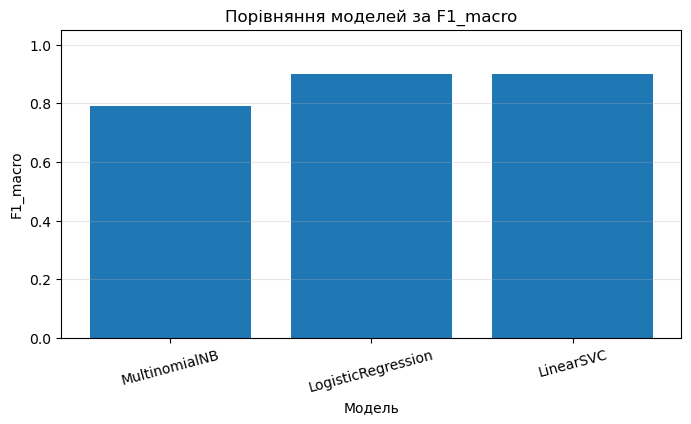

In [107]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["f1_macro"])
plt.title("Порівняння моделей за F1_macro")
plt.xlabel("Модель")
plt.ylabel("F1_macro")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.show()


## 10. Матриця помилок

Для детальнішого аналізу побудуємо *матрицю помилок* для моделі *Logistic Regression*.  
За потреби аналогічно можна побудувати її і для інших моделей.


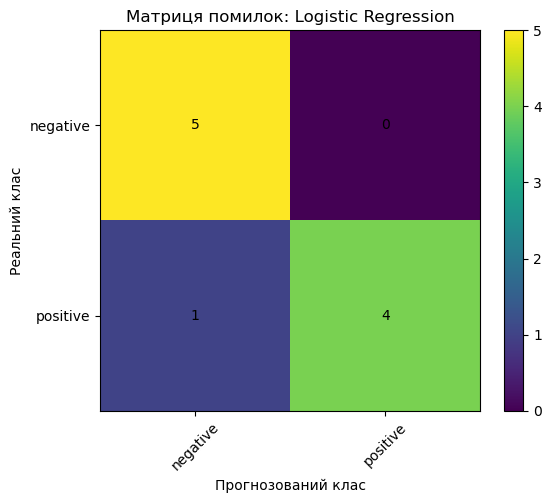

In [108]:
labels_sorted = sorted(y.unique())
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels_sorted)

plt.figure(figsize=(6, 5))
plt.imshow(cm_lr, interpolation="nearest")
plt.title("Матриця помилок: Logistic Regression")
plt.colorbar()
plt.xticks(range(len(labels_sorted)), labels_sorted, rotation=45)
plt.yticks(range(len(labels_sorted)), labels_sorted)
plt.xlabel("Прогнозований клас")
plt.ylabel("Реальний клас")

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## 11. Інтерпретація ознак у Logistic Regression

Так як у нас бінарна класифікація, то ми маємо один рядок коефіцієнтів, де додатні вказують на позитивний клас, а від'ємні на негативний.


In [111]:
feature_names = vectorizer.get_feature_names_out()
coef_row = lr_model.coef_[0]
class_labels = lr_model.classes_

# 1. Топ-8 слів для другого класу (позитивні коефіцієнти)
top_pos_idx = np.argsort(coef_row)[::-1][:8]
pos_df = pd.DataFrame({
    "term": feature_names[top_pos_idx],
    "weight": np.round(coef_row[top_pos_idx], 4)
})

# 2. Топ-8 слів для першого класу (найбільш від'ємні коефіцієнти)
top_neg_idx = np.argsort(coef_row)[:8]
neg_df = pd.DataFrame({
    "term": feature_names[top_neg_idx],
    "weight": np.round(coef_row[top_neg_idx], 4)
})

print(f"Найхарактерніші терміни для класу '{class_labels[1]}' (позитивний вплив):")
display(pos_df)

print(f"\nНайхарактерніші терміни для класу '{class_labels[0]}' (негативний вплив):")
display(neg_df)

Найхарактерніші терміни для класу 'positive' (позитивний вплив):


,term,weight
0,quick,0.3086
1,communication,0.3065
2,students,0.2835
3,group,0.2832
4,excellent,0.2755
5,results,0.2716
6,use,0.2637
7,well,0.1925



Найхарактерніші терміни для класу 'negative' (негативний вплив):


,term,weight
0,system,-0.4199
1,navigation,-0.3318
2,time,-0.3036
3,failed,-0.2980
4,slow,-0.2913
5,irrelevant,-0.2912
6,several,-0.2871
7,follow,-0.1982


## 12. Коротка інтерпретація результатів

Було проведено аналіз того, які моделі краще підійшли для бінарної класифікації повідомлень різної тональності: негативної та позитивної. Корпус було доповнено до 40 документів, бо малий корпус давав дуже погані результати (лише 33% точності, і всі 3 моделі давали однаковий результат). Також було додано стемінг, який потужно покращив результати. Наївна Байєсова класифікація вважає, що терміни не пов'язані між собою, та обчислює ймовірності появи термінів у виділених класах.
Логістична регресія дає цікаві дані з приводу того, які слова наскільки сильно впливають на рішення класифікатора.
Метод опорних векторів чудово підходить, якщо дані чітко роздільні.
Для нашого варіанту логістична регресія та опорні вектори підійшли якнакраще, бо у нас є два чітких класи, які легко виділити за ключовими словами. І тому коефіцієнти, які ставить логістична регресія, є чітким способом розділити класи.
Для позитивного класу ми побачили такі слова, як: quick, communication, students, excellent, well, results тощо. Багато цих слів з'явились тут через те, що вони йдуть одразу після реально ключових, як "quick communication" чи "excellent results". Отже, комунікація працює добре і застосунок гарно підходить для навчання.
Для негативного класу ми побачили: system, navigation, time, failed, slow, irrelevant тощо. Тобто можна зробити висновки, що слова system, navigation і time з'являються у негативному ключі, а отже і із цими областями у застосунку є проблеми.

## Висновки

У ході лабораторної роботи було:

- сформовано *розмічений* навчальний корпус документів;
- виконано базове очищення текстів;
- побудовано *TF-IDF*-матрицю;
- навчено моделі *Multinomial Naive Bayes*, *Logistic Regression* та *Linear SVM*;
- обчислено основні метрики якості класифікації;
- побудовано *матрицю помилок*;
- проаналізовано найхарактерніші ознаки класів.

Отже, у цій роботі ми перейшли від *векторного подання тексту* і *кластеризації* до *керованої класифікації документів*, тобто до повноцінного застосування моделей навчання з учителем у задачах аналізу текстової інформації.


## Контрольні питання

1. У чому полягає відмінність між *класифікацією* та *кластеризацією* текстових документів?
Класифікація відносить тексти до наперед відомих класів, а кластеризація самостійно групує схожі документи без міток.
2. Чому для класифікації потрібен *розмічений корпус*?
Для класифікації потрібен розмічений корпус, щоб модель навчилася зв’язку між текстами та правильними класами.
3. Яку роль відіграє *TF-IDF* у задачах класифікації тексту?
TF-IDF перетворює тексти у числові ознаки та підсилює важливі слова для точнішого навчання класифікатора.
4. У чому полягає основна ідея *Naive Bayes*?
Основна ідея Naive Bayes полягає в обчисленні ймовірності класу за словами документа за припущення незалежності ознак.
5. Чому *логістична регресія* в задачах тексту є саме класифікатором?
Логістична регресія є класифікатором, бо прогнозує ймовірність належності об’єкта до певного класу.
6. Що показує *матриця помилок*?
Матриця помилок показує кількість правильних і неправильних передбачень для кожного класу.
7. Чому метрика *accuracy* не завжди є достатньою?
Accuracy не завжди достатня, бо при незбалансованих класах може давати оманливо високий результат.
8. Які переваги мають лінійні моделі для інтерпретації текстових ознак?
Лінійні моделі зручні для інтерпретації, бо ваги ознак показують внесок окремих слів у рішення моделі.
